In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.tree import plot_tree 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("dataset.csv")

In [3]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.02,1.0,0.0,?,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.02,4.0,0.0,?,normal,notpresent,notpresent,...,38,6000,?,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,?,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.01,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              400 non-null    int64
 1   age             400 non-null    str  
 2   bp              400 non-null    str  
 3   sg              400 non-null    str  
 4   al              400 non-null    str  
 5   su              400 non-null    str  
 6   rbc             400 non-null    str  
 7   pc              400 non-null    str  
 8   pcc             400 non-null    str  
 9   ba              400 non-null    str  
 10  bgr             400 non-null    str  
 11  bu              400 non-null    str  
 12  sc              400 non-null    str  
 13  sod             400 non-null    str  
 14  pot             400 non-null    str  
 15  hemo            400 non-null    str  
 16  pcv             400 non-null    str  
 17  wc              400 non-null    str  
 18  rc              400 non-null    str  
 19

In [5]:
df.isnull()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
396,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
397,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
398,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [6]:
for i in df.columns:
    print(df[i].value_counts())

id
0      1
1      1
2      1
3      1
4      1
      ..
395    1
396    1
397    1
398    1
399    1
Name: count, Length: 400, dtype: int64
age
60.0    19
65.0    17
48.0    12
50.0    12
55.0    12
        ..
90.0     1
78.0     1
2.0      1
22.0     1
79.0     1
Name: count, Length: 77, dtype: int64
bp
80.0     116
70.0     112
60.0      71
90.0      53
100.0     25
?         12
50.0       5
110.0      3
140.0      1
180.0      1
120.0      1
Name: count, dtype: int64
sg
1.02     106
1.01      84
1.025     81
1.015     75
?         47
1.005      7
Name: count, dtype: int64
al
0.0    199
?       46
1.0     44
2.0     43
3.0     43
4.0     24
5.0      1
Name: count, dtype: int64
su
0.0    290
?       49
2.0     18
3.0     14
4.0     13
1.0     13
5.0      3
Name: count, dtype: int64
rbc
normal      201
?           152
abnormal     47
Name: count, dtype: int64
pc
normal      259
abnormal     76
?            65
Name: count, dtype: int64
pcc
notpresent    354
present        42
?         

In [7]:
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.02,1.0,0.0,?,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.02,4.0,0.0,?,normal,notpresent,notpresent,...,38,6000,?,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,?,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.01,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.02,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.02,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [8]:
for i in df.columns:
    print(i)
    print(df[i].describe())
    print("\n\n")

id
count    400.000000
mean     199.500000
std      115.614301
min        0.000000
25%       99.750000
50%      199.500000
75%      299.250000
max      399.000000
Name: id, dtype: float64



age
count      400
unique      77
top       60.0
freq        19
Name: age, dtype: object



bp
count      400
unique      11
top       80.0
freq       116
Name: bp, dtype: object



sg
count      400
unique       6
top       1.02
freq       106
Name: sg, dtype: object



al
count     400
unique      7
top       0.0
freq      199
Name: al, dtype: object



su
count     400
unique      7
top       0.0
freq      290
Name: su, dtype: object



rbc
count        400
unique         3
top       normal
freq         201
Name: rbc, dtype: object



pc
count        400
unique         3
top       normal
freq         259
Name: pc, dtype: object



pcc
count            400
unique             3
top       notpresent
freq             354
Name: pcc, dtype: object



ba
count            400
unique             3
top   

In [9]:
(df == "?").any()

id                False
age                True
bp                 True
sg                 True
al                 True
su                 True
rbc                True
pc                 True
pcc                True
ba                 True
bgr                True
bu                 True
sc                 True
sod                True
pot                True
hemo               True
pcv                True
wc                 True
rc                 True
htn                True
dm                 True
cad                True
appet              True
pe                 True
ane                True
classification    False
dtype: bool

In [10]:
numeric_cols = ["age","bp","sg","al","su","bgr","bu","sc","sod","pot","hemo","pcv","wc","rc"]

for col in numeric_cols:
    df[col] = df[col].replace("?", np.nan)
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())   

In [11]:
categorical_cols = ["rbc","pc","pcc","ba","htn","dm","cad","appet","pe","ane"]

for col in categorical_cols:
    df[col] = df[col].replace("?", np.nan)
    df[col] = df[col].fillna(df[col].mode())   

In [12]:
(df == "?").any()

id                False
age               False
bp                False
sg                False
al                False
su                False
rbc               False
pc                False
pcc               False
ba                False
bgr               False
bu                False
sc                False
sod               False
pot               False
hemo              False
pcv               False
wc                False
rc                False
htn               False
dm                False
cad               False
appet             False
pe                False
ane               False
classification    False
dtype: bool

In [13]:
lb = LabelEncoder()

df["rbc"] = lb.fit_transform(df["rbc"])
df["pc"] = lb.fit_transform(df["pc"])
df["pcc"] = lb.fit_transform(df["pcc"])
df["ba"] = lb.fit_transform(df["ba"])
df["htn"] = lb.fit_transform(df["htn"])
df["dm"] = lb.fit_transform(df["dm"])
df["cad"] = lb.fit_transform(df["cad"])
df["appet"] = lb.fit_transform(df["appet"])
df["pe"] = lb.fit_transform(df["pe"])
df["ane"] = lb.fit_transform(df["ane"])
df["classification"] = lb.fit_transform(df["classification"])
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,...,44.0,7800.0,5.2,1,4,1,0,0,0,1
1,1,7.0,50.0,1.020,4.0,0.0,2,1,0,0,...,38.0,6000.0,4.8,0,3,1,0,0,0,1
2,2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,...,31.0,7500.0,4.8,0,4,1,1,0,1,1
3,3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,...,32.0,6700.0,3.9,1,3,1,1,1,1,1
4,4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,...,35.0,7300.0,4.6,0,3,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,1,1,0,0,...,47.0,6700.0,4.9,0,3,1,0,0,0,2
396,396,42.0,70.0,1.025,0.0,0.0,1,1,0,0,...,54.0,7800.0,6.2,0,3,1,0,0,0,2
397,397,12.0,80.0,1.020,0.0,0.0,1,1,0,0,...,49.0,6600.0,5.4,0,3,1,0,0,0,2
398,398,17.0,60.0,1.025,0.0,0.0,1,1,0,0,...,51.0,7200.0,5.9,0,3,1,0,0,0,2


In [14]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='str')

In [ ]:
x = df[["age", 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr','bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad','appet', 'pe', 'ane']]

In [16]:
y = df[["classification"]]

In [17]:
# df.to_csv("cleaned_dataset.csv")

In [18]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
Xtrain

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,11.2,32.0,6700.0,3.9,1,3,1,1,1,1
18,60.0,100.0,1.025,0.0,3.0,2,1,0,0,263.0,...,12.7,37.0,11400.0,4.3,1,4,2,0,0,0
202,78.0,60.0,1.020,0.0,0.0,2,2,0,0,114.0,...,8.0,24.0,8000.0,4.8,0,4,1,0,0,1
250,40.0,80.0,1.025,0.0,0.0,1,1,0,0,140.0,...,15.0,48.0,10400.0,4.5,0,3,1,0,0,0
274,19.0,80.0,1.020,0.0,0.0,1,1,0,0,107.0,...,14.4,44.0,8000.0,4.8,0,3,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,46.0,60.0,1.010,1.0,0.0,1,1,0,0,163.0,...,9.8,28.0,14600.0,3.2,1,4,1,0,0,0
106,50.0,90.0,1.020,0.0,0.0,2,2,0,0,89.0,...,6.0,17.0,6500.0,4.8,1,4,1,0,1,1
270,23.0,80.0,1.025,0.0,0.0,1,1,0,0,111.0,...,14.3,41.0,7200.0,5.0,0,3,1,0,0,0
348,38.0,80.0,1.020,0.0,0.0,1,1,0,0,99.0,...,13.6,44.0,7300.0,6.4,0,3,1,0,0,0


In [20]:
Xtest

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
209,19.0,70.0,1.020,0.0,0.0,2,1,0,0,121.0,...,11.5,40.0,6900.0,4.8,0,3,1,0,0,0
280,47.0,80.0,1.020,0.0,0.0,2,2,0,0,93.0,...,13.3,52.0,8100.0,5.2,0,3,1,0,0,0
33,60.0,100.0,1.020,2.0,0.0,0,0,0,0,140.0,...,10.1,29.0,8000.0,4.8,1,3,1,1,0,0
210,59.0,100.0,1.015,4.0,2.0,1,1,0,0,255.0,...,7.3,20.0,9800.0,3.9,1,4,2,0,0,1
93,73.0,100.0,1.010,3.0,2.0,0,0,1,0,295.0,...,9.2,30.0,7000.0,3.2,1,4,2,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,48.0,110.0,1.015,3.0,0.0,0,1,1,0,106.0,...,8.6,26.0,5000.0,2.5,1,3,2,0,0,1
227,57.0,80.0,1.015,0.0,0.0,2,1,0,0,120.0,...,11.3,36.0,7200.0,3.8,1,4,1,0,0,0
369,75.0,70.0,1.020,0.0,0.0,1,1,0,0,107.0,...,13.6,46.0,10300.0,4.8,0,3,1,0,0,0
176,21.0,90.0,1.010,4.0,0.0,1,0,1,1,107.0,...,8.3,23.0,12400.0,3.9,0,3,1,0,0,1


In [21]:
Ytrain

,classification
3,1
18,1
202,1
250,2
274,2
...,...
71,1
106,1
270,2
348,2


In [22]:
Ytest

,classification
209,1
280,2
33,1
210,1
93,1
...,...
246,1
227,1
369,2
176,1


In [23]:
model = DecisionTreeClassifier(criterion='gini', max_depth=3)
model.fit(Xtrain, Ytrain)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples 

In [24]:
y_pred = model.predict(Xtest)
y_pred

array([1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1,
       2, 2, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1,
       2, 2, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2])

In [25]:
Ytest

,classification
209,1
280,2
33,1
210,1
93,1
...,...
246,1
227,1
369,2
176,1


In [26]:
print("Accuracy", accuracy_score(Ytest, y_pred)*100)

Accuracy 98.75


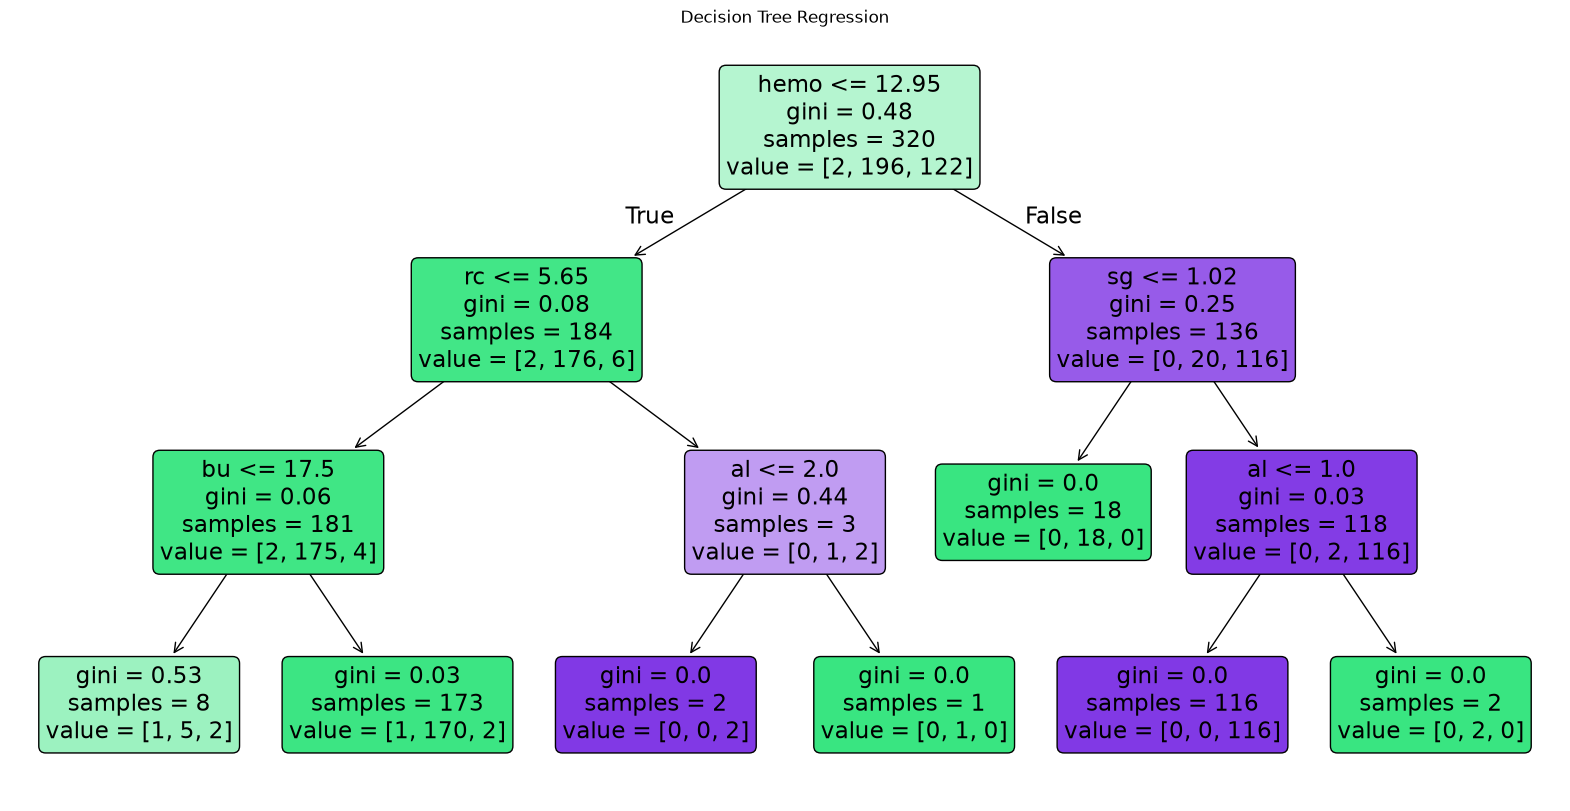

In [27]:
plt.figure(figsize=(20, 10))

plot_tree(model, feature_names=x.columns, filled=True, rounded=True, precision=2)

plt.title("Decision Tree Regression")

plt.show()